#  Загрузка и предварительная обработка данных
 Был взят датасет Stocks Market


 ## Загрузка датасета и создание персонализированного датасета
Из-за большого объёма набора данных может потребоваться больше ресурсов для его обработки.
Выборочно возьмём отдельные файлы из всей совокупности для лабораторной работы.


In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# путь к папке stocks
STOCKS_PATH = r"C:\Users\nikpa\OneDrive\Документы\Николя Учёба\Магистратура ВШЭ\1 курс\JupyterProject\data\stocks"

# находим все CSV файлы в папке
all_files = glob.glob(os.path.join(STOCKS_PATH, "*.csv"))

print(f"Найдено файлов: {len(all_files)}")

for f in all_files[:5]:
    print(os.path.basename(f))


Найдено файлов: 5884
A.csv
AA.csv
AACG.csv
AAL.csv
AAMC.csv


In [4]:
# сортируем файлы по размеру — от большего к меньшему
# большой файл = больше исторических данных = больше строк
all_files_sorted = sorted(
    all_files,
    key=lambda f: os.path.getsize(f),
    reverse=True
)

# берём первые 100 файлов
files_to_use = all_files_sorted[:100]

print("Топ-10 крупнейших файлов:")
for f in files_to_use[:10]:
    size_kb = os.path.getsize(f) // 1024
    print(f"{os.path.basename(f):20} {size_kb} KB")


Топ-10 крупнейших файлов:
HPQ.csv              1628 KB
GE.csv               1606 KB
DIS.csv              1602 KB
ARNC.csv             1569 KB
AA.csv               1568 KB
IP.csv               1545 KB
MO.csv               1450 KB
BA.csv               1438 KB
KO.csv               1412 KB
MRO.csv              1362 KB


In [5]:
# объединяем все файлы в одну таблицу
dataframes = []

for filepath in files_to_use:
    df = pd.read_csv(filepath)
    ticker = os.path.basename(filepath).replace(".csv", "")
    df["ticker"] = ticker
    dataframes.append(df)

df_all = pd.concat(dataframes, ignore_index=True)

print(f"Итого строк: {len(df_all)}")
print(f"Итого компаний: {df_all['ticker'].nunique()}")
print(f"Колонки: {list(df_all.columns)}")
df_all.head()


Итого строк: 1205202
Итого компаний: 100
Колонки: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'ticker']


,Date,Open,High,Low,Close,Adj Close,Volume,ticker
0,1962-01-02,0.131273,0.131273,0.124177,0.124177,0.006887,2480300.0,HPQ
1,1962-01-03,0.124177,0.124177,0.121516,0.122846,0.006813,507300.0,HPQ
2,1962-01-04,0.122846,0.126838,0.117968,0.120185,0.006666,845500.0,HPQ
3,1962-01-05,0.119742,0.119742,0.117525,0.117525,0.006518,338200.0,HPQ
4,1962-01-08,0.117525,0.119299,0.115307,0.119299,0.006617,873700.0,HPQ


Информация по признакам
 * Date — Дата торгов
 * Open — Цена открытия
 * High — Максимальная цена за день
 * Low — Минимальная цена за день
 * Close — Цена закрытия (скорректированная на сплиты)
 * Adj Close — Скорректированная цена закрытия (учитывает сплиты и дивиденды)
 * Volume — Объём торгов
* ticker — Тикер компании (добавлен при объединении файлов)


 **Шаг 1: Проверка пропусков**


In [6]:
print(f"Пропуски до удаления:")
print(df_all.isnull().sum())

df_all = df_all.dropna()
print(f"\nСтрок после удаления пропусков: {len(df_all)}")


Пропуски до удаления:
Date          0
Open         24
High         24
Low          24
Close        24
Adj Close    24
Volume       24
ticker        0
dtype: int64

Строк после удаления пропусков: 1205178


**Шаг 2: Проверка дубликатов**


In [7]:
print(f"Дубликатов: {df_all.duplicated().sum()}")
df_all = df_all.drop_duplicates()
print(f"Строк после удаления дубликатов: {len(df_all)}")


Дубликатов: 0
Строк после удаления дубликатов: 1205178


**Шаг 3: Обработка типов данных**


In [8]:
# Date — конвертируем из строки в дату
df_all["Date"] = pd.to_datetime(df_all["Date"])
print(f"Тип Date: {df_all['Date'].dtype}")

# Volume — проверяем есть ли дробные значения
has_fractional = (df_all["Volume"] % 1 != 0).sum()
print(f"Строк с дробным Volume: {has_fractional}")

# дробных нет — делаем int
df_all["Volume"] = df_all["Volume"].astype(int)

df_all.info()


Тип Date: datetime64[ns]
Строк с дробным Volume: 0
<class 'pandas.core.frame.DataFrame'>
Index: 1205178 entries, 0 to 1205201
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   Date       1205178 non-null  datetime64[ns]
 1   Open       1205178 non-null  float64       
 2   High       1205178 non-null  float64       
 3   Low        1205178 non-null  float64       
 4   Close      1205178 non-null  float64       
 5   Adj Close  1205178 non-null  float64       
 6   Volume     1205178 non-null  int64         
 7   ticker     1205178 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 82.8+ MB


**Шаг 4: Проверка выбросов**
Удаляем только физически невозможные значения.
 Статистические выбросы (IQR) — только смотрим, не удаляем.
 Резкий рост Volume это реальное рыночное событие, а не ошибка данных.


In [9]:
print("-- Шаг 4.1: Отрицательные и нулевые значения --")
price_cols = ["Open", "High", "Low", "Close", "Adj Close"]
for col in price_cols:
    count = (df_all[col] <= 0).sum()
    print(f"  {col} <= 0: {count} строк")

count_vol = (df_all["Volume"] <= 0).sum()
print(f"  Volume <= 0: {count_vol} строк")

# удаляем строки с некорректными ценами
for col in price_cols:
    df_all = df_all[df_all[col] > 0]
df_all = df_all[df_all["Volume"] > 0]
print(f"  Строк после очистки: {len(df_all)}\n")

print("-- Шаг 4.2: Логические противоречия --")
invalid_lh = (df_all["Low"] > df_all["High"]).sum()
print(f"  Low > High: {invalid_lh} строк")
df_all = df_all[df_all["Low"] <= df_all["High"]]
print(f"  Строк после очистки: {len(df_all)}\n")

print("-- Шаг 4.3: Open и Close вне диапазона [Low, High] --")
invalid_open = ((df_all["Open"] < df_all["Low"]) |
                (df_all["Open"] > df_all["High"])).sum()
invalid_close = ((df_all["Close"] < df_all["Low"]) |
                 (df_all["Close"] > df_all["High"])).sum()
print(f"  Open вне [Low, High]: {invalid_open} строк")
print(f"  Close вне [Low, High]: {invalid_close} строк")

df_all = df_all[
    (df_all["Open"] >= df_all["Low"]) &
    (df_all["Open"] <= df_all["High"])
]
df_all = df_all[
    (df_all["Close"] >= df_all["Low"]) &
    (df_all["Close"] <= df_all["High"])
]
print(f"  Строк после очистки: {len(df_all)}\n")

print("-- Шаг 4.4: Статистические выбросы (IQR) — только смотрим --")
for col in ["Open", "High", "Low", "Close", "Adj Close", "Volume"]:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1
    count = ((df_all[col] < Q1 - 1.5*IQR) |
             (df_all[col] > Q3 + 1.5*IQR)).sum()
    print(f"  Выбросов {col}: {count} ({count/len(df_all)*100:.1f}%) — не удаляем")

print(f"\nИтого строк после всех проверок: {len(df_all)}")


-- Шаг 4.1: Отрицательные и нулевые значения --
  Open <= 0: 121257 строк
  High <= 0: 0 строк
  Low <= 0: 0 строк
  Close <= 0: 0 строк
  Adj Close <= 0: 0 строк
  Volume <= 0: 20710 строк
  Строк после очистки: 1063256

-- Шаг 4.2: Логические противоречия --
  Low > High: 0 строк
  Строк после очистки: 1063256

-- Шаг 4.3: Open и Close вне диапазона [Low, High] --
  Open вне [Low, High]: 26 строк
  Close вне [Low, High]: 1 строк
  Строк после очистки: 1063229

-- Шаг 4.4: Статистические выбросы (IQR) — только смотрим --
  Выбросов Open: 76388 (7.2%) — не удаляем
  Выбросов High: 76244 (7.2%) — не удаляем
  Выбросов Low: 76514 (7.2%) — не удаляем
  Выбросов Close: 76403 (7.2%) — не удаляем
  Выбросов Adj Close: 84550 (8.0%) — не удаляем
  Выбросов Volume: 98383 (9.3%) — не удаляем

Итого строк после всех проверок: 1063229


**Шаг 5: Создание целевого признака target**
 Задача — бинарная классификация:
 * 1 -> цена Adj Close завтра ВЫШЕ чем сегодня
 * 0 -> цена Adj Close завтра НИЖЕ чем сегодня


In [10]:
# сортируем по компании и дате — ОБЯЗАТЕЛЬНО перед shift
df_all = df_all.sort_values(["ticker", "Date"]).reset_index(drop=True)

# shift(-1) берёт значение следующей строки (следующий день)
# groupby гарантирует что сдвиг происходит внутри одной компании
df_all["target"] = (
    df_all.groupby("ticker")["Adj Close"].shift(-1) > df_all["Adj Close"]
).astype("Int64")

# удаляем последнюю строку каждой компании — у неё нет следующего дня
df_all = df_all.dropna(subset=["target"])
df_all["target"] = df_all["target"].astype(int)

print("Распределение целевого признака:")
print(df_all["target"].value_counts())
print(f"\nПроцентное соотношение:")
print(df_all["target"].value_counts(normalize=True).mul(100).round(2))
print(f"\nВсего строк: {len(df_all)}")


Распределение целевого признака:
target
0    564161
1    499068
Name: count, dtype: int64

Процентное соотношение:
target
0    53.06
1    46.94
Name: proportion, dtype: float64

Всего строк: 1063229


**Шаг 6: Feature Engineering**

 Создаём новые признаки из существующих.

 ВАЖНО: делаем это ДО нормализации — на оригинальных данных.

 Иначе скользящие средние будут коррелировать 1.00 с Adj Close.


In [11]:
# volatility — создаём ПЕРВЫМ пока High и Low ещё существуют
# разница между максимумом и минимумом дня = нервозность рынка
# df_all["volatility"] = df_all["High"] - df_all["Low"]
df_all["volatility"] = (df_all["High"] - df_all["Low"]) / df_all["Low"]
# сначала считаем сырые скользящие средние
ma5_raw = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=5).mean()
)
ma20_raw = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=20).mean()
)

# MA5_ratio — отношение текущей цены к средней за 5 дней
# > 1.0 = цена выше краткосрочного тренда (бычий сигнал)
# < 1.0 = цена ниже краткосрочного тренда (медвежий сигнал)
df_all["MA5_ratio"] = df_all["Adj Close"] / ma5_raw

# MA20_ratio — отношение текущей цены к средней за 20 дней
df_all["MA20_ratio"] = df_all["Adj Close"] / ma20_raw

# MA_cross — разница между краткосрочным и долгосрочным трендом
# > 0 = краткосрочный тренд сильнее долгосрочного (бычий сигнал)
# < 0 = долгосрочный тренд сильнее (медвежий сигнал)
df_all["MA_cross"] = ma5_raw - ma20_raw

# price_change — процентное изменение цены за день
# pct_change() = (сегодня - вчера) / вчера
df_all["price_change"] = df_all.groupby("ticker")["Adj Close"].transform(
    lambda x: x.pct_change()
)

# день недели: 0=понедельник, 4=пятница
df_all["day_of_week"] = df_all["Date"].dt.dayofweek

# месяц: 1=январь, 12=декабрь
df_all["month"] = df_all["Date"].dt.month

# удаляем ненужные колонки
# Open, High, Low — дублируют Adj Close (корреляция 0.99-1.00)
# Close — заменён на Adj Close (более честная цена)
df_all = df_all.drop(columns=["Open", "High", "Low", "Close"])

# удаляем строки с NaN (первые 19 строк каждой компании не имеют MA20)
df_all = df_all.dropna()

print(f"Строк после Feature Engineering: {len(df_all)}")
print(f"Колонки: {list(df_all.columns)}")


Строк после Feature Engineering: 1061329
Колонки: ['Date', 'Adj Close', 'Volume', 'ticker', 'target', 'volatility', 'MA5_ratio', 'MA20_ratio', 'MA_cross', 'price_change', 'day_of_week', 'month']


**Шаг 7: EDA — анализ данных**

 Проводим EDA ДО нормализации — на оригинальных данных.

 Так графики показывают реальные значения, а не числа от 0 до 1.


**График 1: Распределение целевого признака**


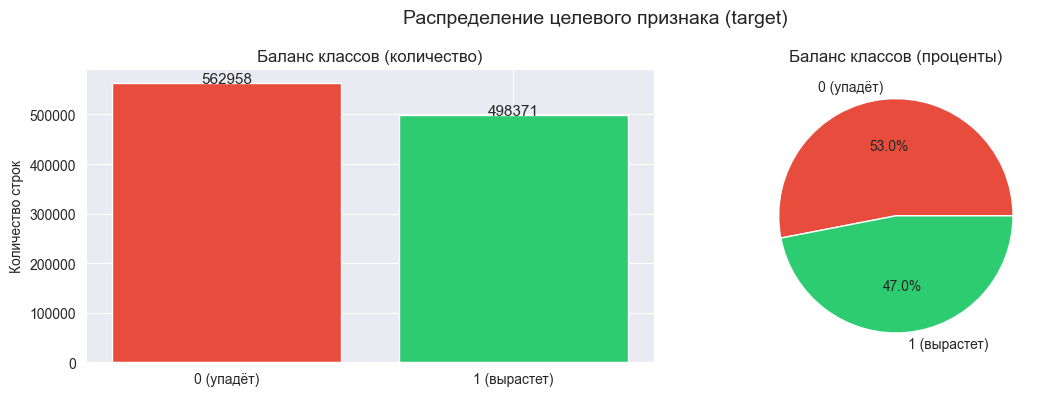

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df_all["target"].value_counts()
target_labels = ["0 (упадёт)", "1 (вырастет)"]

axes[0].bar(target_labels, target_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Баланс классов (количество)")
axes[0].set_ylabel("Количество строк")

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, str(v), ha="center", fontsize=11)

target_pct = df_all["target"].value_counts(normalize=True) * 100
axes[1].pie(
    target_pct.values,
    labels=target_labels,
    autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"]
)
axes[1].set_title("Баланс классов (проценты)")

plt.suptitle("Распределение целевого признака (target)", fontsize=14)
plt.tight_layout()
plt.show()


 **График 2: Распределение Adj Close и Volume**


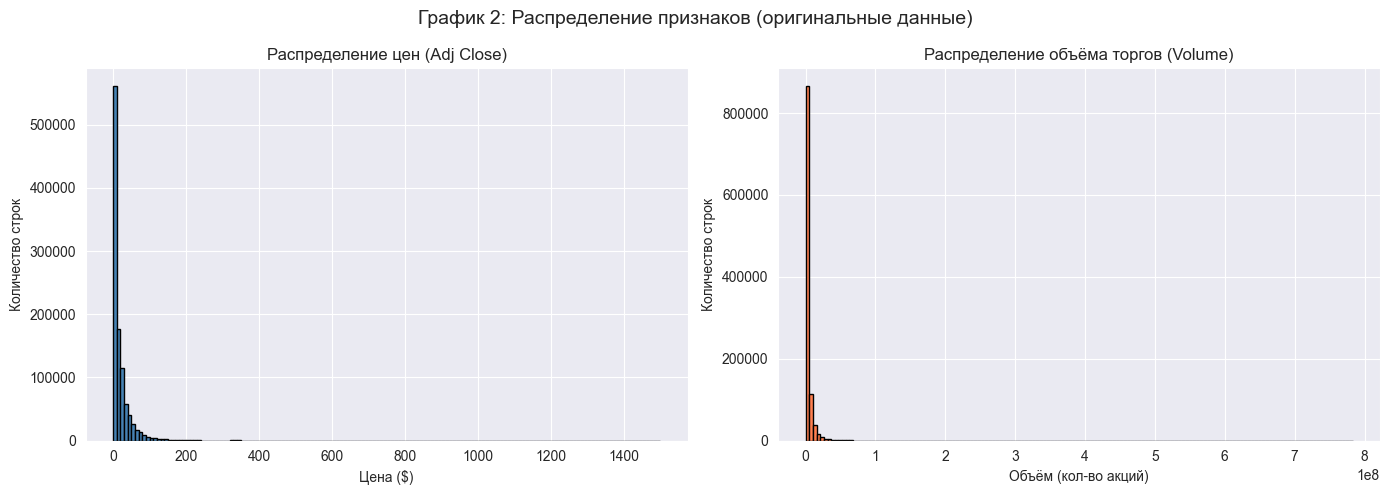

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# гистограмма Adj Close — на оригинальных данных видны реальные цены
axes[0].hist(df_all["Adj Close"], bins=150, color="steelblue", edgecolor="black")
axes[0].set_title("Распределение цен (Adj Close)")
axes[0].set_xlabel("Цена ($)")
axes[0].set_ylabel("Количество строк")

# гистограмма Volume
axes[1].hist(df_all["Volume"], bins=150, color="coral", edgecolor="black")
axes[1].set_title("Распределение объёма торгов (Volume)")
axes[1].set_xlabel("Объём (кол-во акций)")
axes[1].set_ylabel("Количество строк")

plt.suptitle("График 2: Распределение признаков (оригинальные данные)", fontsize=14)
plt.tight_layout()
plt.show()


 **График 3: Количество записей по годам**


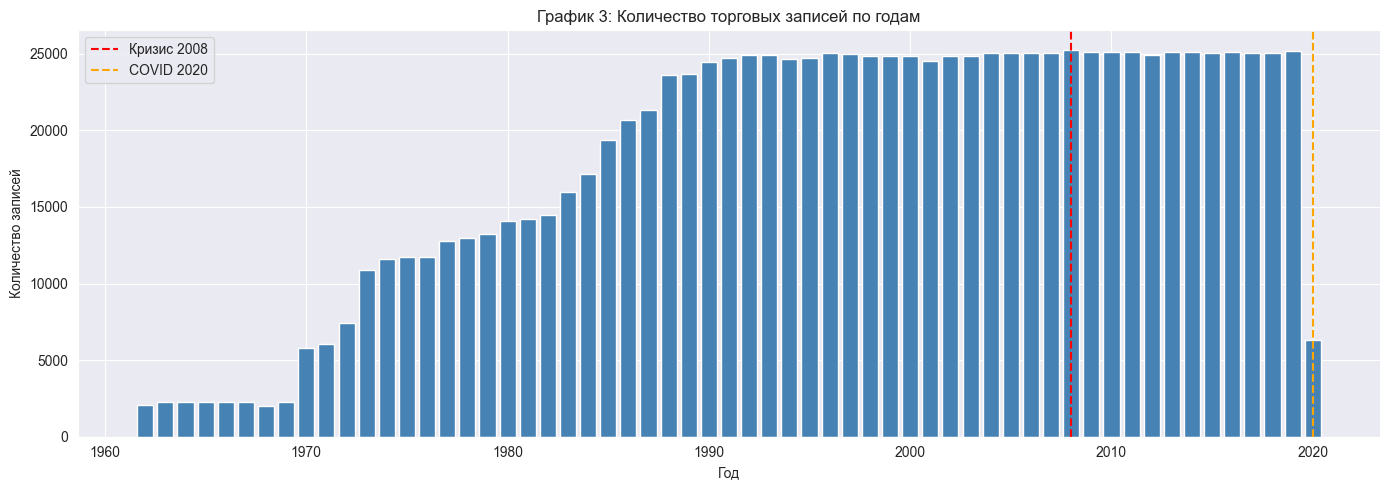

In [14]:
df_all["year"] = df_all["Date"].dt.year
records_per_year = df_all.groupby("year").size()

plt.figure(figsize=(14, 5))
plt.bar(records_per_year.index, records_per_year.values, color="steelblue")
plt.title("График 3: Количество торговых записей по годам")
plt.xlabel("Год")
plt.ylabel("Количество записей")
plt.axvline(x=2008, color="red", linestyle="--", label="Кризис 2008")
plt.axvline(x=2020, color="orange", linestyle="--", label="COVID 2020")
plt.legend()
plt.tight_layout()
plt.show()

df_all = df_all.drop(columns=["year"])


 **График 4: Корреляционная матрица**


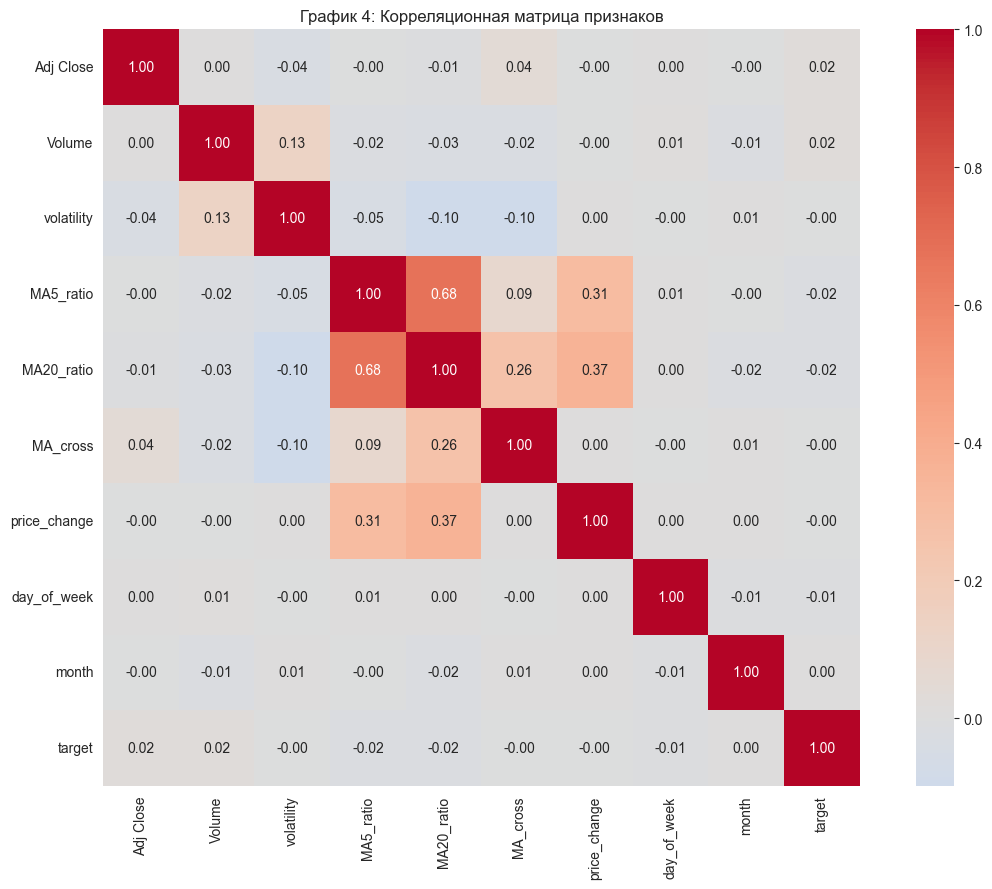

Корреляция каждого признака с target (по убыванию):
Volume          0.023648
Adj Close       0.023172
MA20_ratio     -0.015721
MA5_ratio      -0.015597
day_of_week    -0.006044
MA_cross       -0.004086
volatility     -0.001933
price_change   -0.000678
month           0.000298
Name: target, dtype: float64


In [15]:
numeric_cols = ["Adj Close", "Volume", "volatility", "MA5_ratio",
                "MA20_ratio", "MA_cross", "price_change",
                "day_of_week", "month", "target"]

correlation_matrix = df_all[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("График 4: Корреляционная матрица признаков")
plt.tight_layout()
plt.show()

print("Корреляция каждого признака с target (по убыванию):")
print(correlation_matrix["target"].drop("target").sort_values(
    key=abs, ascending=False
))


 **График 5: Временной ряд одной компании**


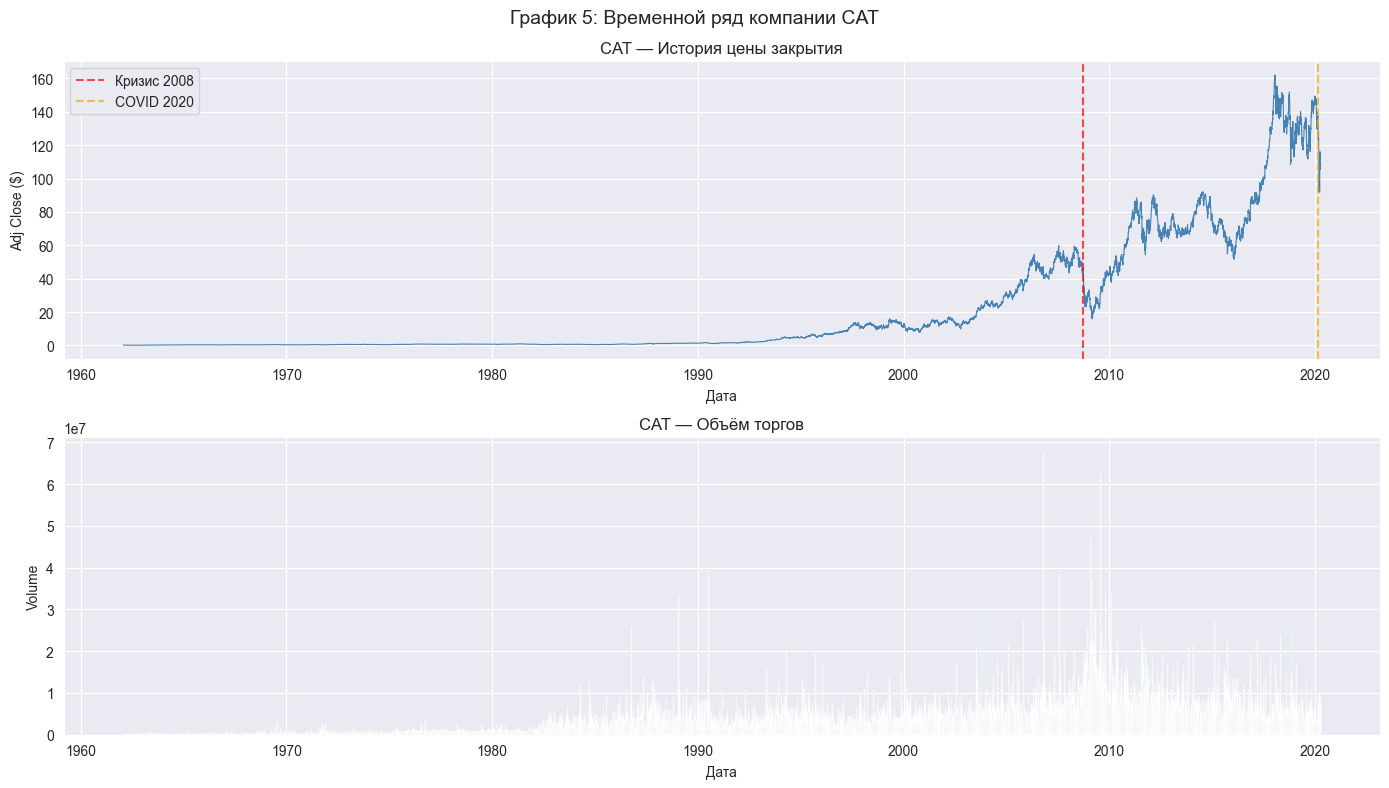

In [16]:
top_ticker = df_all["ticker"].value_counts().index[0]
company_data = df_all[df_all["ticker"] == top_ticker].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(company_data["Date"], company_data["Adj Close"],
             color="steelblue", linewidth=0.8)
axes[0].set_title(f"{top_ticker} — История цены закрытия")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Adj Close ($)")
axes[0].axvline(pd.Timestamp("2008-09-15"), color="red",
                linestyle="--", alpha=0.7, label="Кризис 2008")
axes[0].axvline(pd.Timestamp("2020-03-01"), color="orange",
                linestyle="--", alpha=0.7, label="COVID 2020")
axes[0].legend()

axes[1].bar(company_data["Date"], company_data["Volume"],
            color="steelblue", alpha=0.7, width=1)
axes[1].set_title(f"{top_ticker} — Объём торгов")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Volume")

plt.suptitle(f"График 5: Временной ряд компании {top_ticker}", fontsize=14)
plt.tight_layout()
plt.show()


 **Шаг 8: Нормализация**

ВАЖНО: нормализуем ПОСЛЕ EDA — чтобы графики показывали реальные значения.

 Нормализуем только признаки для модели. Date, ticker, target — не трогаем.


In [17]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# признаки которые нормализуем
features_to_scale = ["Adj Close", "Volume", "volatility",
                     "MA5_ratio", "MA20_ratio", "MA_cross",
                     "price_change"]

# создаём нормализатор
scaler = MinMaxScaler()

# fit_transform — изучает данные и применяет нормализацию
df_all[features_to_scale] = scaler.fit_transform(df_all[features_to_scale])

print("Минимальные значения после нормализации:")
print(df_all[features_to_scale].min())
print("\nМаксимальные значения после нормализации:")
print(df_all[features_to_scale].max())


Минимальные значения после нормализации:
Adj Close       0.0
Volume          0.0
volatility      0.0
MA5_ratio       0.0
MA20_ratio      0.0
MA_cross        0.0
price_change    0.0
dtype: float64

Максимальные значения после нормализации:
Adj Close       1.0
Volume          1.0
volatility      1.0
MA5_ratio       1.0
MA20_ratio      1.0
MA_cross        1.0
price_change    1.0
dtype: float64


 Сохраняем скалер — он понадобится Consumer'у чтобы нормализовывать
 новые данные из Kafka теми же параметрами что и при обучении модели.


In [18]:
joblib.dump(scaler, "models/scaler.pkl")
print(f"Скалер сохранён. Размер: {os.path.getsize('models/scaler.pkl')} байт")


Скалер сохранён. Размер: 1295 байт


 **Шаг 9: Сохранение датасета**


In [19]:
import os

# путь к папке проекта — для ноутбука это папка где лежит .ipynb файл
BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_PATH = os.path.join(BASE_DIR, "data", "dataset_combined.csv")

df_all.to_csv(DATA_PATH, index=False)
print(f"Датасет сохранён в: {DATA_PATH}")


# df_all.to_csv("data/dataset_combined.csv", index=False)
#
# print(f"Датасет сохранён в data/dataset_combined.csv")
print(f"Итого строк: {len(df_all)}")
print(f"Итого колонок: {len(df_all.columns)}")
print(f"Колонки: {list(df_all.columns)}")

Датасет сохранён в: C:\Users\nikpa\OneDrive\Документы\Николя Учёба\Магистратура ВШЭ\1 курс\JupyterProject\data\dataset_combined.csv
Итого строк: 1061329
Итого колонок: 12
Колонки: ['Date', 'Adj Close', 'Volume', 'ticker', 'target', 'volatility', 'MA5_ratio', 'MA20_ratio', 'MA_cross', 'price_change', 'day_of_week', 'month']
